# Inspect the raw multi-omics data with UMAP

In [1]:
import pandas as pd
import json
from hgnn.hypergraph import *

In [25]:
def umap_visualize(features, cell_stage, method='UMAP', palette=None, s=40):
    from umap import UMAP
    from sklearn.manifold import TSNE

    import seaborn as sns
    import matplotlib.pyplot as plt

    # plt.figure(figsize=(6,4))
    vec = eval(method)(n_components=2).fit_transform(features)
    sns.scatterplot(x=vec[:, 0], y=vec[:, 1], hue=cell_stage,
                    hue_order=sorted(set(cell_stage)), palette=palette,
                    s=s, linewidth=0, alpha=0.5)
    plt.legend()
    plt.title(method)

    # ---- 计算每个类的中心并标注 ----
    df = pd.DataFrame({'UMAP_1': vec[:, 0], 'UMAP_2': vec[:, 1], 'label': cell_stage})
    centroids = df.groupby('label')[['UMAP_1', 'UMAP_2']].mean()

    for label, row in centroids.iterrows():
        plt.text(row['UMAP_1'], row['UMAP_2'], str(label),
                 fontsize=9, ha='center', va='center',)
    plt.tight_layout()

    from scoit.cell_analysis import cluster_evaluate

    return cluster_evaluate(vec, cell_stage)

## sc-GEM

In [18]:
cr = HyperGraphCreator({
        'expr': './data/sc_GEM/expression_data.csv',
        'methy': './data/sc_GEM/methylation_data.csv',
    }, cell_key='Cell ID', dataname='sc_GEM', prefix=Path('./data'))
cr.load_and_preprocess_data()
cr.load_cell_stage()

Begin to load multi omics data {'expr': './data/sc_GEM/expression_data.csv', 'methy': './data/sc_GEM/methylation_data.csv'}
Load data done, time: 0.009050607681274414
Rename columns
Name: expr, Columns: Index(['ADAM33_expr', 'AFP_expr', 'AK123759_expr', 'ALDH3A1_expr', 'BMP7_expr',
       'CDH1_expr', 'CDH22_expr', 'CDX2_expr', 'CER1_expr', 'CHL1_expr',
       'COL20A1_expr', 'COL23A1_expr', 'CYBRD1_expr', 'DAZL_expr',
       'DNMT3B_expr', 'DNMT3L_expr', 'DPPA3_expr', 'EPHB3_expr', 'FGF4_expr',
       'FOSL1_expr', 'FOXD2_expr', 'HAND1_expr', 'HLX-AS1_expr', 'IGF2_expr',
       'JARID2_expr', 'KCNQ2_expr', 'LEFTY_expr', 'LTBR_expr', 'LUM_expr',
       'LY86-AS1_expr', 'MMP9_expr', 'MYC_expr', 'NANOG_expr', 'NESTIN_expr',
       'NFATC1_expr', 'NFIX_expr', 'NKX2-5_expr', 'NXRA8_expr', 'OCT4_expr',
       'OTX2_expr', 'PIWIL1_expr', 'PLEKHH3_expr', 'PRDM14_expr', 'SALL4_expr',
       'SOX2_expr', 'STON2P1_expr', 'SULT1A1_expr', 'TBX3_expr', 'TFAP2A_expr',
       'TFCP2L1_expr', 'TGFBR2_

{'NMI': 0.6324258774615079,
 'ARI': 0.5302343254491794,
 'FMI': 0.593076681761292}

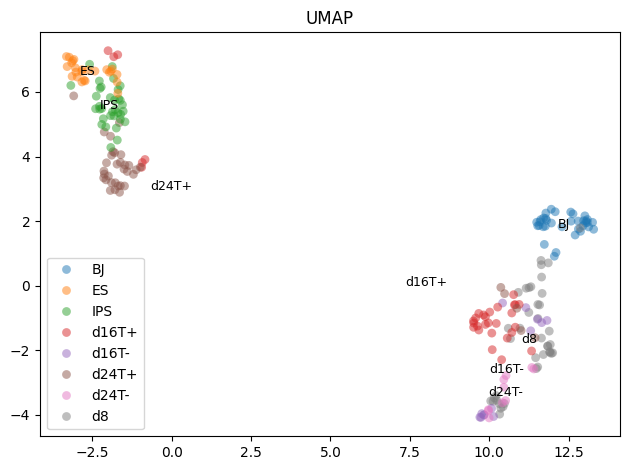

In [19]:
umap_visualize(features=cr.df, cell_stage=cr.cell_stage)

## PEA-STA

In [20]:
cr = HyperGraphCreator({
        'expr': './data/PEA_STA/expression_data.csv',
        'protein': './data/PEA_STA/protein_data.csv',
    }, cell_key='Cells ', dataname='PEA_STA', prefix=Path('./data'))
cr.load_and_preprocess_data()
cr.load_cell_stage()

Begin to load multi omics data {'expr': './data/PEA_STA/expression_data.csv', 'protein': './data/PEA_STA/protein_data.csv'}
Load data done, time: 0.015291929244995117
Rename columns
Name: expr, Columns: Index(['AKT1_expr', 'APC_expr', 'APP_expr', 'AURKB_expr', 'AXIN1_expr',
       'AXIN2_expr', 'BAX_expr', 'BCL2_expr', 'BCL2L1_expr', 'BCL6_expr',
       ...
       'THY1_expr', 'TNFRSF10B_expr', 'TNFRSF1A_expr', 'TP53_expr',
       'TRADD_expr', 'TUBB3_expr', 'TWSG1_expr', 'VEGFA_expr', 'VIM_expr',
       'XIAP_expr'],
      dtype='object', length=141)
Name: protein, Columns: Index(['AKT1_protein', 'APC_protein', 'APP_protein', 'AURKB_protein',
       'AXIN1_protein', 'AXIN2_protein', 'BAX_protein', 'BCL2_protein',
       'BCL2L1_protein', 'BCL6_protein',
       ...
       'THY1_protein', 'TNFRSF10B_protein', 'TNFRSF1A_protein', 'TP53_protein',
       'TRADD_protein', 'TUBB3_protein', 'TWSG1_protein', 'VEGFA_protein',
       'VIM_protein', 'XIAP_protein'],
      dtype='object', length=1

{'NMI': 0.5835736547165747,
 'ARI': 0.49324140556832535,
 'FMI': 0.6993979562313523}

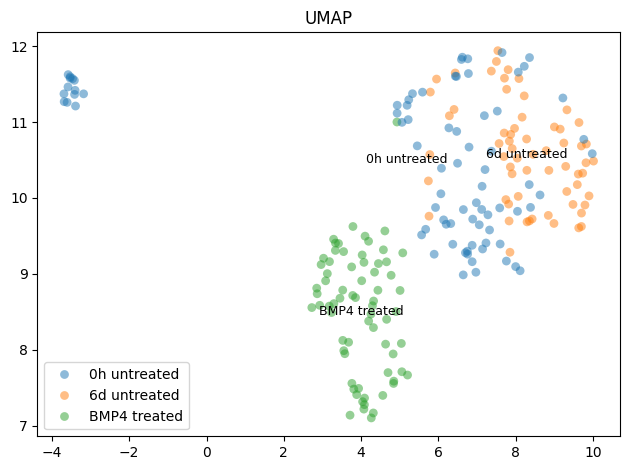

In [23]:
umap_visualize(features=cr.df, cell_stage=cr.cell_stage)


## sci-CAR

In [24]:
cr = HyperGraphCreator({
        'atac': './data/sci_CAR/ATAC_lsi.csv',
        'rna': './data/sci_CAR/RNA_pca.csv',
    }, cell_key='Unnamed: 0', dataname='sci_CAR', prefix=Path('./data'))
cr.load_cell_stage()
cr.load_and_preprocess_data()

Begin to load multi omics data {'atac': './data/sci_CAR/ATAC_lsi.csv', 'rna': './data/sci_CAR/RNA_pca.csv'}
Load data done, time: 0.2292802333831787
Rename columns
Name: atac, Columns: Index(['LSI_1_atac', 'LSI_2_atac', 'LSI_3_atac', 'LSI_4_atac', 'LSI_5_atac',
       'LSI_6_atac', 'LSI_7_atac', 'LSI_8_atac', 'LSI_9_atac', 'LSI_10_atac',
       'LSI_11_atac', 'LSI_12_atac', 'LSI_13_atac', 'LSI_14_atac',
       'LSI_15_atac', 'LSI_16_atac', 'LSI_17_atac', 'LSI_18_atac',
       'LSI_19_atac', 'LSI_20_atac', 'LSI_21_atac', 'LSI_22_atac',
       'LSI_23_atac', 'LSI_24_atac', 'LSI_25_atac', 'LSI_26_atac',
       'LSI_27_atac', 'LSI_28_atac', 'LSI_29_atac', 'LSI_30_atac',
       'LSI_31_atac', 'LSI_32_atac', 'LSI_33_atac', 'LSI_34_atac',
       'LSI_35_atac', 'LSI_36_atac', 'LSI_37_atac', 'LSI_38_atac',
       'LSI_39_atac', 'LSI_40_atac', 'LSI_41_atac', 'LSI_42_atac',
       'LSI_43_atac', 'LSI_44_atac', 'LSI_45_atac', 'LSI_46_atac',
       'LSI_47_atac', 'LSI_48_atac', 'LSI_49_atac', 'LSI_

{'NMI': 0.5499931924192781,
 'ARI': 0.45211121922950276,
 'FMI': 0.5214459988880574}

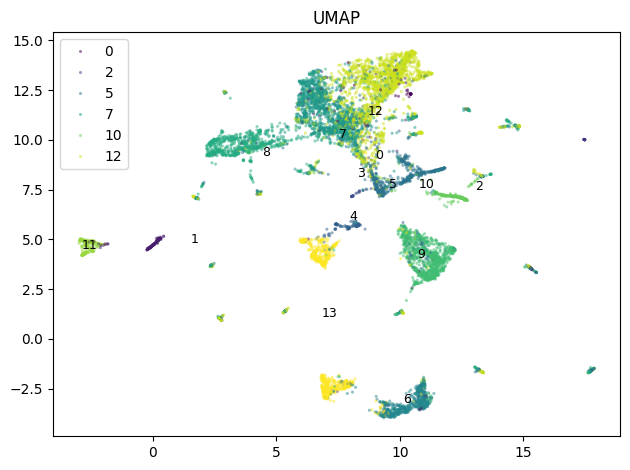

In [26]:
umap_visualize(features=cr.df, cell_stage=cr.cell_stage, palette="viridis", s=5)


## scNMT

In [27]:
cr = HyperGraphCreator({
        'expr': './data/scNMT/expression_data_300.csv',
        'promoter_acc': './data/scNMT/promoter_acc_data_300.csv',
        'promoter_methy': './data/scNMT/promoter_methy_data_300.csv',
    }, cell_key=None, dataname='scNMT', prefix=Path('./data'),
      read_csv_args=dict(sep=' ', header=None))
cr.load_cell_stage()
cr.load_and_preprocess_data()

Begin to load multi omics data {'expr': './data/scNMT/expression_data_300.csv', 'promoter_acc': './data/scNMT/promoter_acc_data_300.csv', 'promoter_methy': './data/scNMT/promoter_methy_data_300.csv'}
Load data done, time: 0.3294992446899414
Rename columns
Name: expr, Columns: Index(['0_expr', '1_expr', '2_expr', '3_expr', '4_expr', '5_expr', '6_expr',
       '7_expr', '8_expr', '9_expr',
       ...
       '290_expr', '291_expr', '292_expr', '293_expr', '294_expr', '295_expr',
       '296_expr', '297_expr', '298_expr', '299_expr'],
      dtype='object', length=300)
Name: promoter_acc, Columns: Index(['0_promoter_acc', '1_promoter_acc', '2_promoter_acc', '3_promoter_acc',
       '4_promoter_acc', '5_promoter_acc', '6_promoter_acc', '7_promoter_acc',
       '8_promoter_acc', '9_promoter_acc',
       ...
       '290_promoter_acc', '291_promoter_acc', '292_promoter_acc',
       '293_promoter_acc', '294_promoter_acc', '295_promoter_acc',
       '296_promoter_acc', '297_promoter_acc', '298_pr

In [32]:
cr.df.fillna(0, inplace=True)

/public/congfeng4/miniconda3/envs/py39/lib/python3.9/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


{'NMI': 0.1367875398268583,
 'ARI': 0.11379882929401554,
 'FMI': 0.4704218595940784}

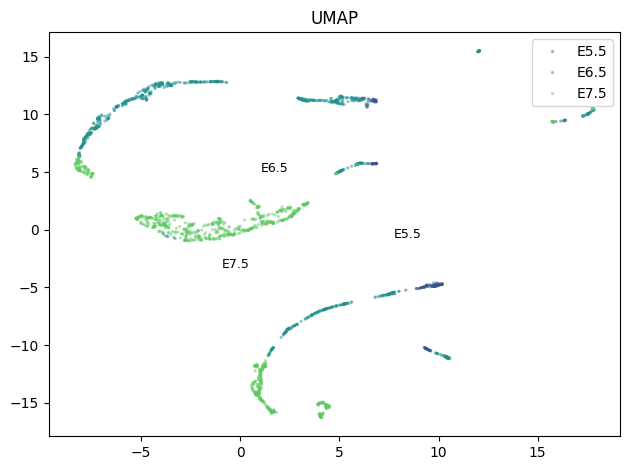

In [33]:
umap_visualize(features=cr.df, cell_stage=cr.cell_stage, palette="viridis", s=5)
